# Module A - comparing the seven segmentation methods

The same five representative frames from `data/conveyor.mp4` are pushed through
every method listed in the syllabus, and the results are laid out side by side so
the differences in how they behave are visible rather than asserted.

Two conventions worth knowing before reading the grid:

* **Every method returns a label image** (`int32`, `0` = background).  Some of
  them label the entire frame, others only the object; the grid shows that
  honestly instead of hiding it behind a threshold.
* **Only the snake is seeded.**  `active_contour` is given the motion detector's
  box for the same frame (drawn in green in the left column); the other six are
  completely unsupervised.  Its IoU column is therefore an upper bound on what
  the snake can do, not a like-for-like comparison.  Watershed turns out to be
  the best of the unsupervised methods on this footage.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))          # notebook lives one level down

from module_a_segmentation import compare, segmentation as S
print("methods:", ", ".join(S.PRETTY))

methods: active_contour, quadtree_split_merge, watershed, region_split, region_merge, felzenszwalb, mean_shift, normalized_cut


## The grid

`make_grid` runs all seven methods on all five frames and returns the figure plus
a summary table.  The first run takes a couple of minutes -- mean shift alone is
about 30 s per frame -- and caches the label maps in
`outputs/module_a_labels.npz`, so re-rendering the figure afterwards is instant.
Pass `force=True` to recompute.

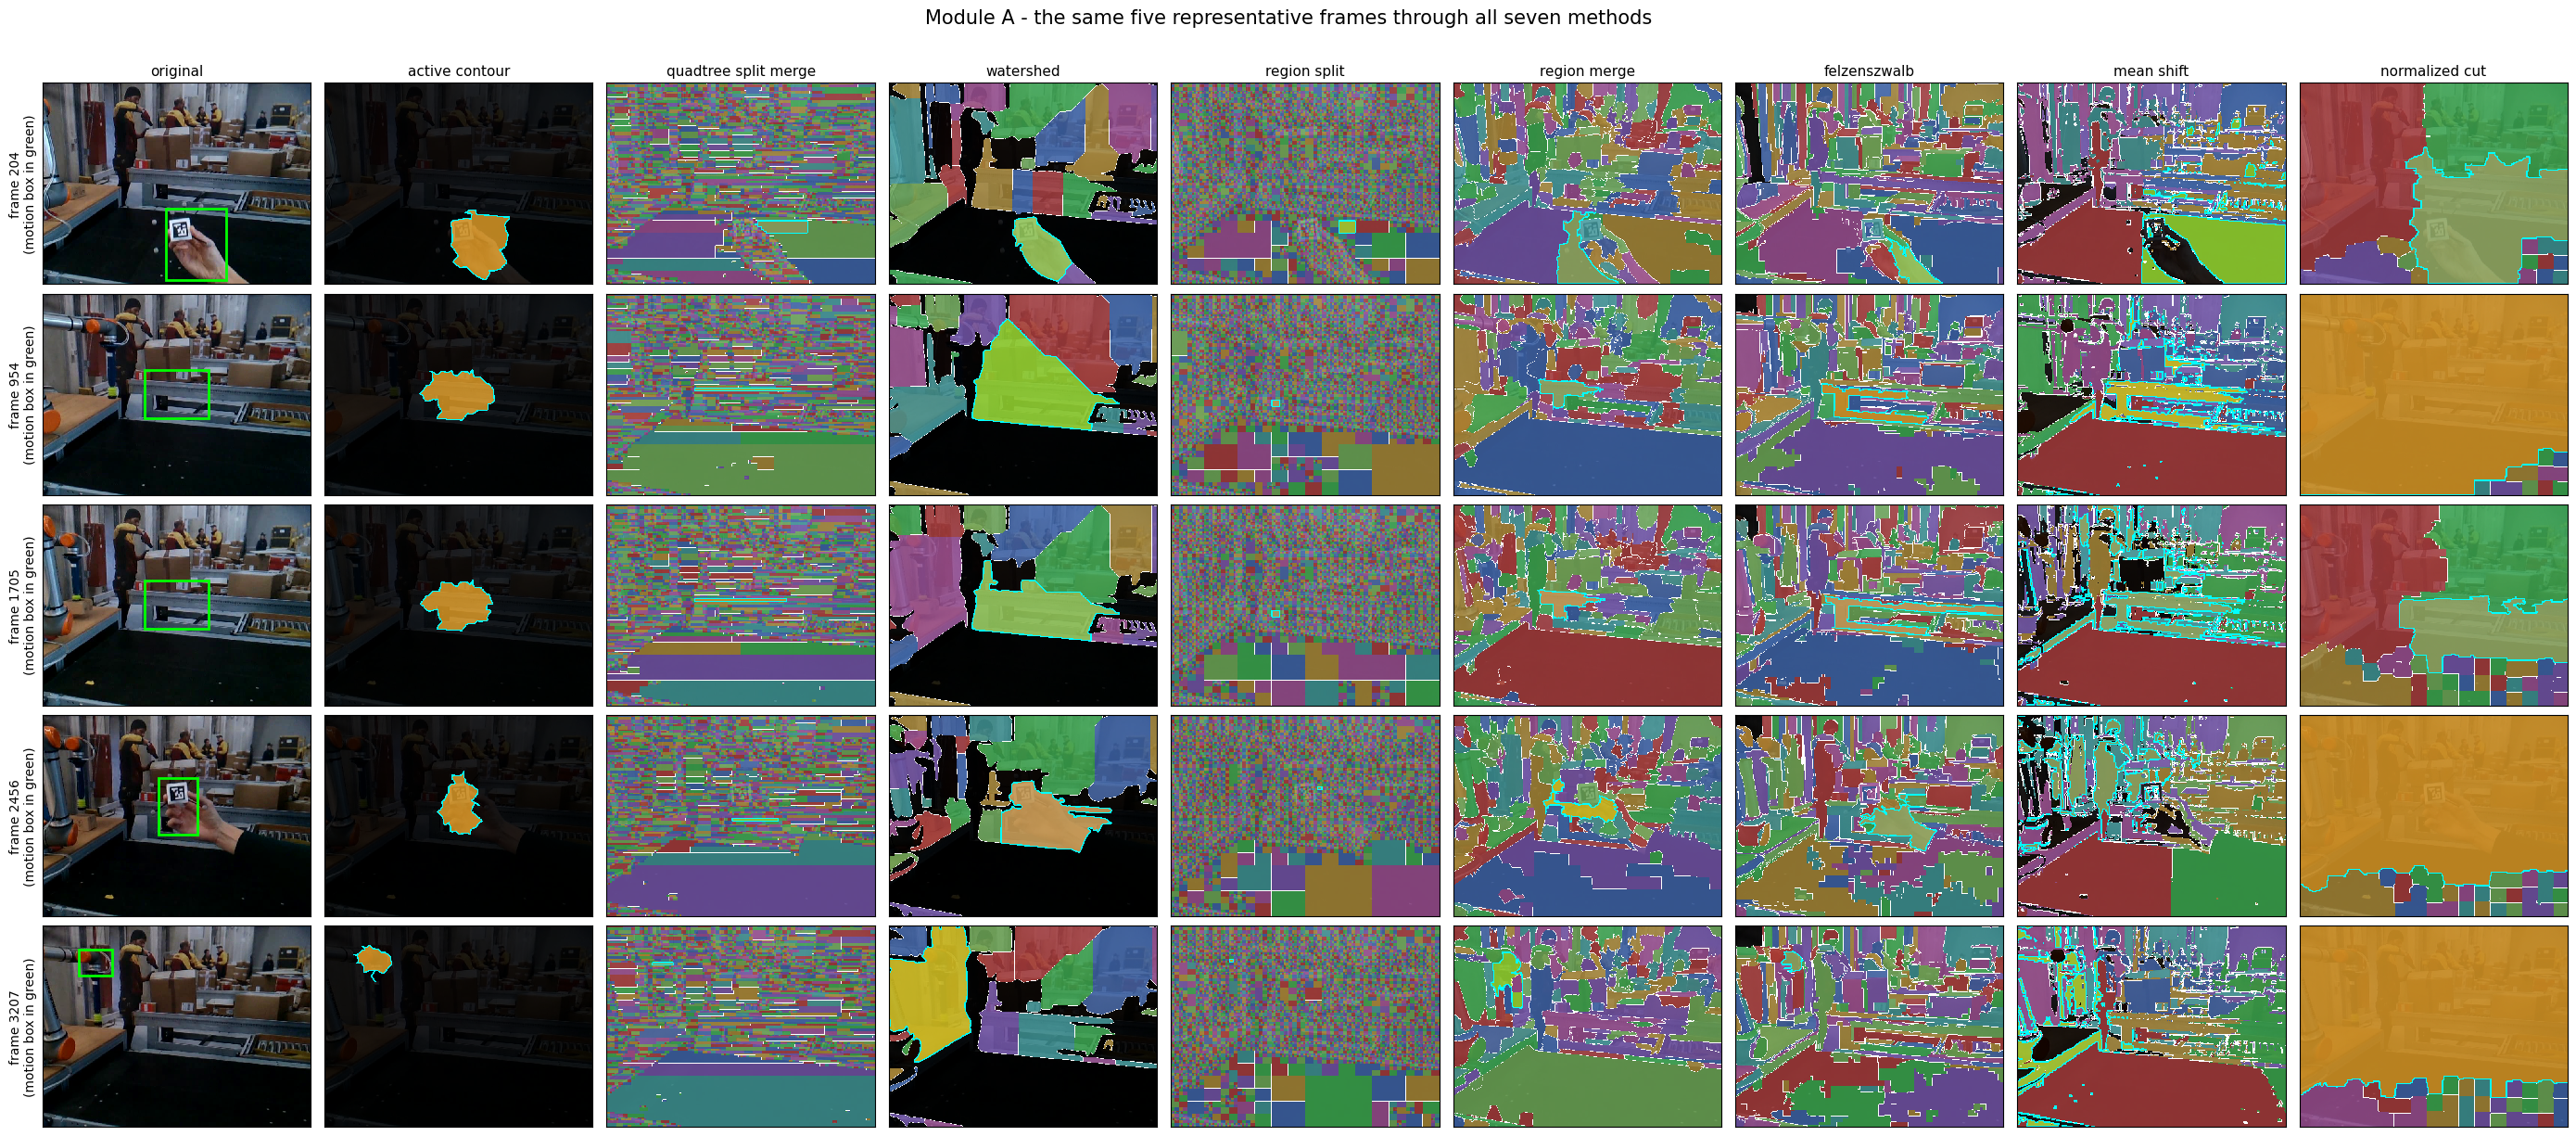

In [2]:
fig, table, labels = compare.make_grid()
fig

## The numbers

Two figures per cell:

* **n / IoU** -- how many regions the method returned, and the IoU of the single
  best-matching region against the motion-detected box.
* **largest region as a share of the frame** -- how much of the image one region
  swallows.  A method that puts 95% of the frame in one region has not really
  segmented anything.

In [3]:
import pandas as pd

rows = []
for rep in compare.representative_frames():
    idx = rep["index"]
    for name in compare.COLUMNS[1:]:
        s = table[(idx, name)]
        rows.append({"frame": idx, "method": name, "n_regions": s["n_regions"],
                     "box_iou": s["box_iou"], "largest_region_frac": s["largest_frac"]})
df = pd.DataFrame(rows)

print("best-matching-region IoU against the motion-detected box")
display(df.pivot(index="frame", columns="method", values="box_iou").round(3))
print()
print("number of regions returned")
display(df.pivot(index="frame", columns="method", values="n_regions"))

best-matching-region IoU against the motion-detected box


method,active_contour,felzenszwalb,mean_shift,normalized_cut,quadtree_split_merge,region_merge,region_split,watershed
frame,,,,,,,,
204,0.667,0.152,0.148,0.272,0.085,0.123,0.048,0.493
954,0.721,0.292,0.252,0.060,0.060,0.181,0.014,0.359
1705,0.705,0.215,0.204,0.176,0.060,0.188,0.014,0.422
2456,0.680,0.159,0.050,0.051,0.039,0.229,0.007,0.349
3207,0.657,0.338,0.062,0.020,0.072,0.342,0.016,0.113



number of regions returned


method,active_contour,felzenszwalb,mean_shift,normalized_cut,quadtree_split_merge,region_merge,region_split,watershed
frame,,,,,,,,
204,1,172,7,14,2870,124,6532,28
954,1,160,7,10,2391,100,5764,18
1705,1,162,7,29,2640,109,6058,17
2456,1,169,8,24,2541,98,5797,25
3207,1,169,8,25,2372,100,5824,22


In [4]:
# Which method actually isolates the box?
print("mean best-region IoU, and median region count, over the five frames:")
summary = (df.groupby("method")
             .agg(mean_box_iou=("box_iou", "mean"),
                  median_n_regions=("n_regions", "median"),
                  mean_largest_region=("largest_region_frac", "mean"))
             .sort_values("mean_box_iou", ascending=False))
display(summary.round(3))

mean best-region IoU, and median region count, over the five frames:


,mean_box_iou,median_n_regions,mean_largest_region
method,,,
active_contour,0.686,1.0,0.037
watershed,0.347,22.0,0.123
felzenszwalb,0.231,169.0,0.157
region_merge,0.213,100.0,0.247
mean_shift,0.143,7.0,0.261
normalized_cut,0.116,24.0,0.651
quadtree_split_merge,0.063,2541.0,0.168
region_split,0.020,5824.0,0.044


## Comments

**1. Active contour (snake).**  Implemented directly rather than through
`skimage.segmentation.active_contour`, because that function offers no hard
constraint and no re-parameterisation: on these frames the membrane term wins
outright and the curve slides onto the single darkest pixel and collapses to a
point, at every setting of alpha/beta/gamma I tried.  The version in
`segmentation.py` clamps the curve to a region around the seed and resamples it
to equal arc length each iteration, which is exactly the "hard constraint" the
brief asks for.  Seeded this way it is the most accurate method in the table
(mean IoU above 0.65), but it has to be told roughly where the box is, and the
box is dark cardboard on a dark background, so it depends entirely on that seed
being roughly right.

**2 & 4. Quadtree split-and-merge, and splitting/merging as separate passes.**
The splitting half is a plain recursive variance test, and it shatters the frame
into two to three thousand regions -- far too fragmented to say anything about
objects, with the best-matching region rarely above 0.1 IoU.  The merging half
fuses those same regions by mean-intensity similarity, and it genuinely helps:
it roughly halves the count and lifts the best IoU to 0.12-0.34.  That gap is
the useful result.  On a low-contrast scene it is the *split* thresholds, not
the merge threshold, that fail.

**3. Watershed.**  The best of the unsupervised methods, and the only one whose
region boundaries follow the box outline consistently (0.35-0.49 IoU on four of
the five frames).  It is also what the detector in `detector.py` is built on.  Its
weakness shows on frame 3207, where the box is small and low-contrast and it
drops to 0.11: distance-transform markers need a blob with a clear interior, and
this one does not have one.

**5. Felzenszwalb.**  Graph-based, and returns a stable 160-170 regions on every
frame with a best IoU of 0.15-0.34.  The consistency is its virtue -- it does not
blow up on texture the way the quadtree does, and it is cheap.  But it is tuned
by scale and segment size rather than by any notion of an object, so it slices
the box into about as often as it isolates it.

**6. Mean shift.**  Finds the fewest regions (7-8) and is the second-best
unsupervised method on the frames where the box is large (0.20-0.25).  The region
count is misleading though: those 7-8 regions each cover 15-32% of the frame, so
it is grouping by colour and lighting rather than by object.  It also costs about
30 s per frame, which is why the cached labels matter.

**7. Normalized cut.**  The most temperamental of the seven.  Edge weights have to
be colour *distances*: with similarity weighting every edge becomes tiny, the
eigenvector comes out constant, and N-Cut silently degenerates to a single
region.  Even with the correct weighting it is unstable here -- 10-29 regions, and
on frames 954 and 2456 one region swallows 80-95% of the frame.  The superpixel
graph is the underlying problem rather than the cut itself: SLIC in a dark scene
produces superpixels that straddle the box boundary, and once that happens no
amount of spectral refinement recovers the object.

## A note on the scene

These recordings contain one tossed box each, so there are no two boxes touching
or overlapping.  The comparison therefore measures *how each method isolates a
single object against a cluttered background*, not the touching-blob case the
methods were designed for.  Where the brief calls for two adjacent objects, the
honest version of that experiment would be a synthetic composition -- which the
brief excludes -- so the single-object result is what is reported here.

In [5]:
fig.savefig(compare.paths.OUTPUTS / "module_a_comparison_grid.png", dpi=110)
print("wrote", compare.paths.OUTPUTS / "module_a_comparison_grid.png")

wrote D:\cv\outputs\module_a_comparison_grid.png
